In [ ]:
from google.colab import files
uploaded=files.upload()

Saving fifa_worldcup_dataset.csv to fifa_worldcup_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_csv("fifa_worldcup_dataset.csv")

In [ ]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [ ]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [ ]:
print(df.isnull().sum())

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df = df.drop(["player_id","player_name","match_id","stadium","city"],axis=1)

In [ ]:
df.head()

,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [ ]:
encoder=LabelEncoder()
df["preferred_foot"]=encoder.fit_transform(df["preferred_foot"])
df["match_result"]=encoder.fit_transform(df["match_result"])
df["nationality"]=encoder.fit_transform(df["nationality"])
df["position"]=encoder.fit_transform(df["position"])



In [ ]:
x=df.drop("tournament_rating",axis=1)
y=df["tournament_rating"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(43680, 69)
(10920, 69)
(43680,)
(10920,)


In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
pred=model.predict(x_test)
print(pred)

[ 5.28588900e+00 -3.89728625e-03 -6.26666985e-04 ... -4.64214573e-03
  3.25099141e-03  6.29105664e+00]


In [ ]:
coefficients=pd.DataFrame({
    "Features":x.columns,
    "Coefficients":model.coef_
}
)
print(coefficients)

                    Features  Coefficients
0                        age     -0.001354
1                nationality      0.001158
2                       team     -0.001799
3              jersey_number     -0.000989
4                   position     -0.002366
..                       ...           ...
64  clutch_performance_score      0.000089
65    total_goals_tournament      0.000003
66  total_assists_tournament      0.001997
67  total_minutes_tournament     -0.002005
68    player_of_match_awards      0.001253

[69 rows x 2 columns]


In [ ]:
print(model.intercept_)

3.6376007326007325


In [ ]:
comparison=pd.DataFrame({
    "Actual":y_test,
    "Predicted":pred
})
print(comparison)

       Actual  Predicted
45140     5.4   5.285889
29111     0.0  -0.003897
44821     0.0  -0.000627
38375     0.0  -0.007088
6788      5.4   5.803924
...       ...        ...
13539     0.0  -0.005405
15555     6.0   6.525324
171       0.0  -0.004642
21257     0.0   0.003251
49985     6.0   6.291057

[10920 rows x 2 columns]


In [ ]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 0.13941488136243568
MSE: 0.052596650138979524
RMSE: 0.2293395956632424
R2: 0.9947562486032437


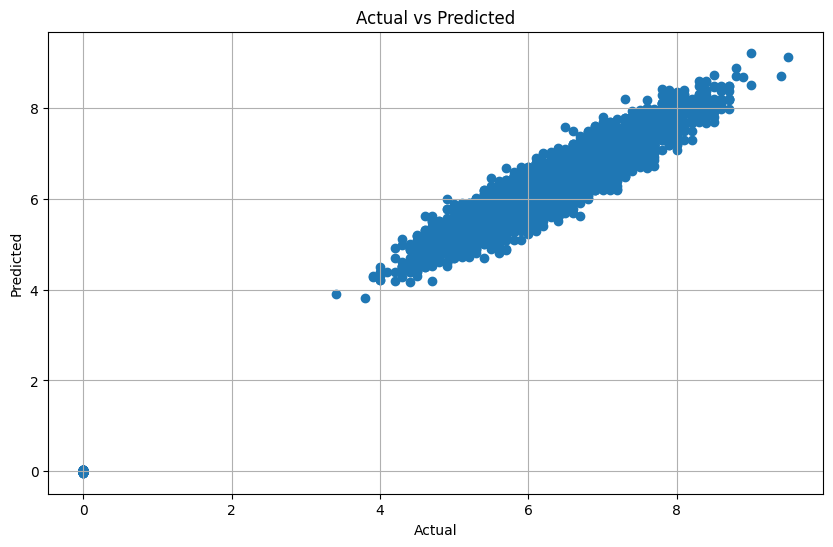

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

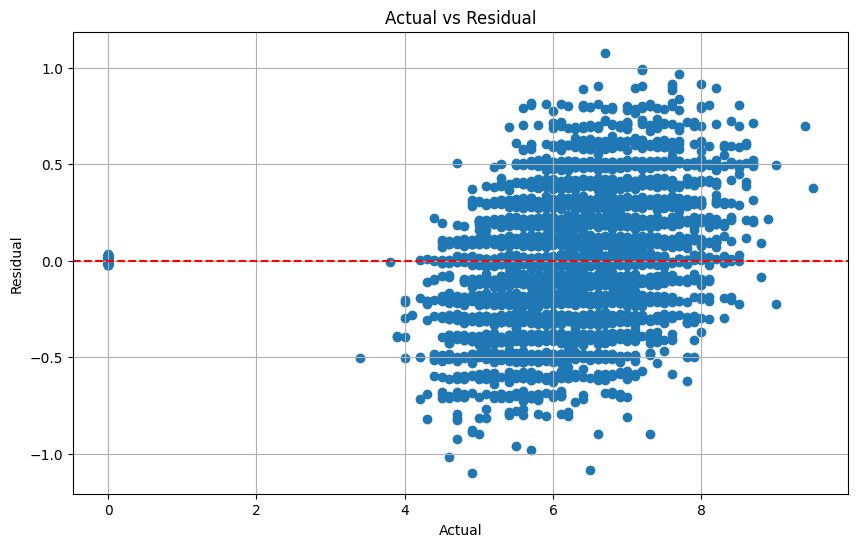

In [ ]:
residual=y_test-pred
plt.figure(figsize=(10,6))
plt.scatter(y_test,residual)
plt.axhline(y=0,color="r",linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Actual vs Residual")
plt.grid(True)
plt.show()

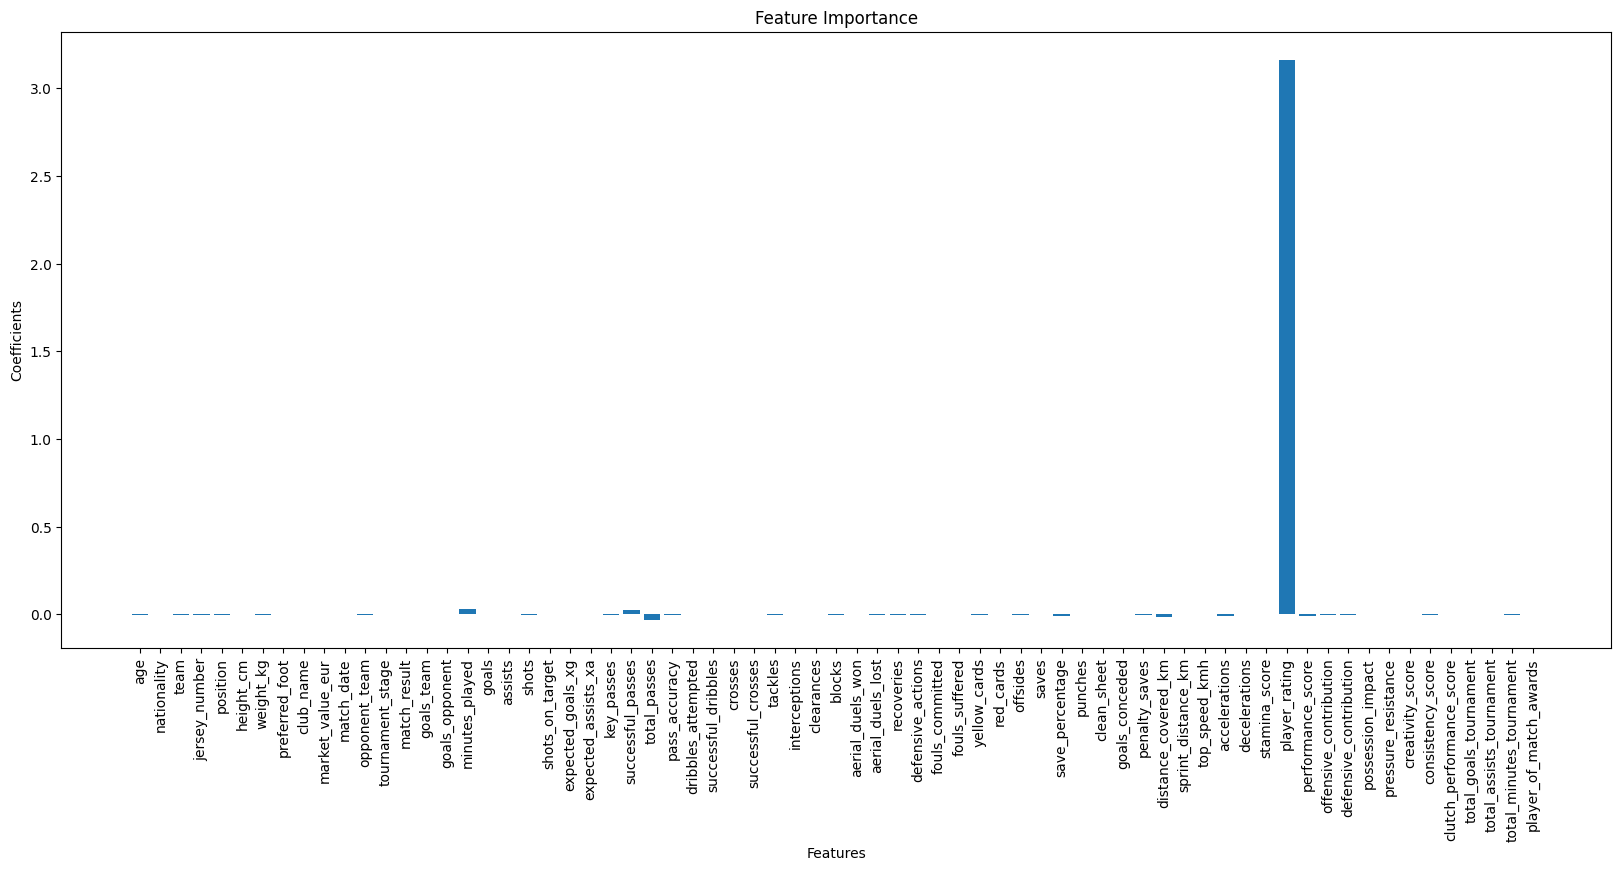

In [ ]:
plt.figure(figsize=(20,8))
plt.bar(
    coefficients["Features"],
    coefficients["Coefficients"]
)
plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.show()